<a href="https://colab.research.google.com/github/AlishbaMalik687-svg/AI-ML-internship_task2/blob/master/Task_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>



* Task 2: Predict Future Stock Prices
* Dataset: Stock market data from Yahoo Finance



Libraries

In [ ]:
!pip install yfinance
import yfinance as yf

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler


Loading Stock Data

In [ ]:
stock=yf.download("AAPL", start="2020-01-01", end="2024-12-31")
stock.head()

/tmp/ipython-input-4197004229.py:1: FutureWarning: YF.download() has changed argument auto_adjust default to True
  stock=yf.download("AAPL", start="2020-01-01", end="2024-12-31")
[*********************100%***********************]  1 of 1 completed


Price,Close,High,Low,Open,Volume
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL
Date,,,,,
2020-01-02,72.400536,72.460799,71.156697,71.409800,135480400
2020-01-03,71.696640,72.455958,71.472462,71.629145,146322800
2020-01-06,72.267929,72.306499,70.568503,70.819201,118387200
2020-01-07,71.928055,72.533095,71.708695,72.277578,108872000
2020-01-08,73.085098,73.386416,71.631544,71.631544,132079200


Spliting 'Target' and 'Feature'

In [ ]:
X=stock.drop("Close", axis=1)   #close waly column ko target krega model
y=stock["Close"]

split 'Train' and 'Test'

In [ ]:
X_train, X_test, y_train, y_test=train_test_split(X, y, test_size=0.2,random_state=42)  # 80% training 20% testing

print('Size of X Train: ',X_train.shape)
print('Size of X Test: ',X_test.shape)
print('Size of y Train: ',y_train.shape)
print('Size of y Test: ',y_test.shape)


Size of X Train:  (1005, 4)
Size of X Test:  (252, 4)
Size of y Train:  (1005, 1)
Size of y Test:  (252, 1)


Standard Scaler

In [ ]:
sc=StandardScaler()
X_train=sc.fit_transform(X_train)   #training data ka mean & std calculate karta hai or usi mean & std se data ko scale karta hai
X_test=sc.transform(X_test)        #sirf transform kiya Kyunkay test data ko bhi training wale mean & std se hi scale karna hota hai.


Model: Linear Regression

In [ ]:
lr=LinearRegression()
lr.fit(X_train, y_train)    #Yahan model training data se learning karta hai.
lr_pred=lr.predict(X_test)   #Ab model test data pe prediction karta hai.


●	Plot actual vs predicted closing prices for comparison.

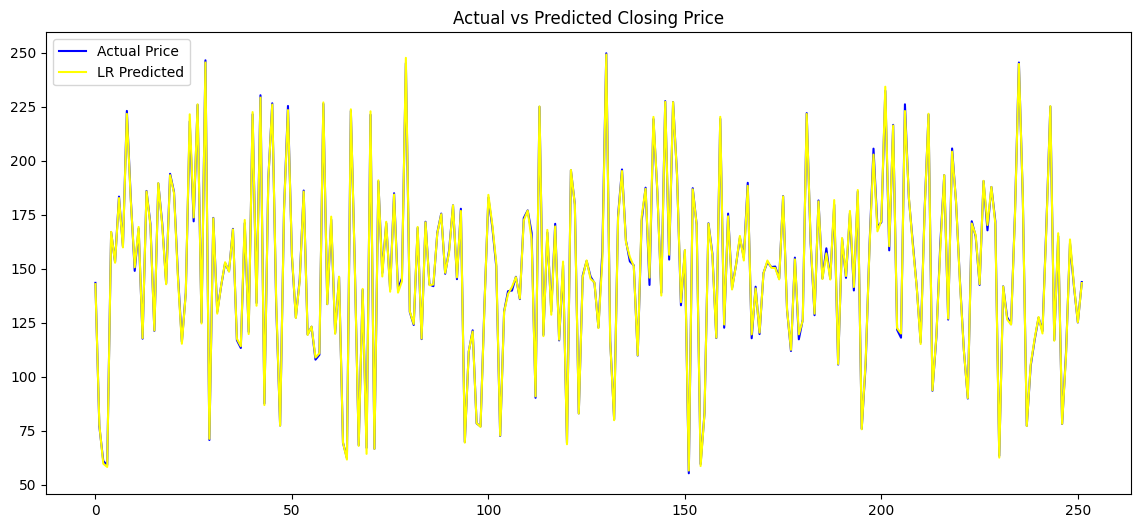

In [ ]:
plt.figure(figsize=(14,6))     #14 → width   6 → height

plt.plot(y_test.values, label="Actual Price", color="blue")    #blue line → actual data   label → legend me name show hoga
plt.plot(lr_pred, label="LR Predicted", color="yellow")   #model ki predicted values plot karti hai   yellow line → prediction


plt.legend()
plt.title("Actual vs Predicted Closing Price")
plt.show()
